In [3]:
# Get all files in min speed limit directory
%load_ext autoreload
%autoreload 2

import sys
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from traffic_sim import *
from mpc_metanet import *
from generate_vt import *
from plotting import *
from param_loader import METANET_Params

import sys, os
# Walk up to the repo root, so this works no matter where Jupyter was launched.
_root = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_root, "src", "paths.py")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find src/paths.py above the working directory")
    _root = _parent
sys.path.insert(0, os.path.join(_root, "src"))

from paths import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# write a function to get the time until free flow is reached with virtual trajectories
# and plot the virtual trajectories on top of the speed field
def time_until_ff(macro_speed_field, time_step, sim_time, num_samples):
    time_between_samples = (sim_time * time_step *60) / (num_samples - 1)
    times = vt_travel_time_stats(macro_speed_field, num_samples=num_samples, time_step=time_step)
    current_ind = 0
    while (np.abs(times[current_ind] - times[current_ind + 1]) > 0.001 or np.abs(times[current_ind+1] - times[current_ind + 2]) > 0.001) and current_ind < len(times)-2:
        current_ind += 1

    return current_ind * time_between_samples
    

In [ ]:
root_path = SYNTHETIC_RESULTS + "/"


additional_path = 'min_speedlimit'
identifier = 'speedlimit'

# additional_path = 'spatial_safety'
# # additional_path = 'temporal_safety'
# identifier = 'safety'

# additional_path = 'gantry'
# identifier = 'location'



def get_all_files(directory, sub_dir, identifier, demand=None):
    """
    Get all files in the specified directory that match the pattern 'min_speed_limit_*.json'.
    
    Args:
        directory (str): The directory to search for files.
    
    Returns:
        list: A list of file paths that match the pattern.
    """
    #pattern = os.path.join(directory + sub_dir + '/', f'optimal_vsl_time0.0_distance6_holdlen1*{identifier}*.csv')
    if demand is not None:
        pattern = os.path.join(directory + sub_dir + '/' + f"demand{demand}/", f'{identifier}*.csv')
    else:
        pattern = os.path.join(directory + sub_dir + '/', f'{identifier}*.csv')

    return glob.glob(pattern)

def get_path_given_val(directory, sub_dir, identifier, value, demand):
    # if value >= 13:
    #     c = value if identifier == "holdlen" else 5
    # else:
    #     c = max(5, 2*value) if identifier == "holdlen" else 5
    # p = max(40, 2*c) if identifier == "holdlen" else 40
    c = max(5, value) if identifier == "holdlen" else 5
    p = max(40, 2*c) if identifier == "holdlen" else 40
    # return os.path.join(directory, sub_dir, f'optimal_vsl_time0.0_distance6_holdlen1_c{c}_p{p}_{identifier}{value}.csv')
    if demand is not None:
        return os.path.join(directory, sub_dir, f"demand{demand}/", f'{identifier}{value}.csv')
    else:
        return os.path.join(directory, sub_dir, f'{identifier}{value}.csv')

def get_constraint_range(all_paths, identifier):
    constraint_range = []
    for path in all_paths:
        # Extract the constraint value from the file name
        start_index = path.rfind(identifier) + len(identifier)
        end_index = path.rfind('.csv')
        if '.' in path[start_index:end_index]:
            constraint_value = float(path[start_index:end_index])
        else:
            constraint_value = int(path[start_index:end_index])
        constraint_range.append(constraint_value)

    return sorted(constraint_range)

In [9]:
demand_dict = dict()
for demand in range(5100, 5800, 100):
    all_paths = get_all_files(root_path, additional_path, identifier, demand=demand)
    constraint_range = get_constraint_range(all_paths, identifier)
    print(constraint_range)
    demand_dict[demand] = (all_paths, constraint_range)

[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]


In [15]:
pred_horizon = 40
control_horizon = 5
sim_time = 720
time_step = 10/3600
L = 400/1000
time_steps = sim_time #+ pred_horizon - control_horizon

total_distance = 10
num_segments = int(total_distance/L)
sim_lanes = {i: 4 if i < num_segments-5 else 2 for i in range(num_segments)}
# sim_lanes = {i: 3 if i < num_segments-5 else 2 for i in range(num_segments)}
segment_len = L
m=num_segments
hold_len = 1

i24params = DefaultParams(num_segments).get_params()

In [19]:
i24_data = False

if i24_data:
    downstream_density = np.load('i24_data/downstream_density_400.npy').reshape(-1)
    traffic_demand = np.load('i24_data/initial_flow_400.npy').reshape(-1)

    sim_time = downstream_density.shape[0]
    time_steps = sim_time + pred_horizon - control_horizon
    while len(downstream_density) < time_steps + 1:
        downstream_density = np.append(downstream_density, downstream_density[-1])
        traffic_demand = np.append(traffic_demand, traffic_demand[-1])
else:
    downstream_density = np.full(time_steps, 0)
    traffic_demand = [5500 if i in range(20, 20 + 180) else 4000 for i in range(time_steps)]

In [20]:
import warnings
warnings.filterwarnings("ignore")
from generate_demand import generate_demand


cc_clipped = []
jam_times = []
demand_cc = dict()


for demand in demand_dict.keys():
    cc = []
    traffic_demand = generate_demand(sim_time, time_step, flow_standard=4000, flow_peak=demand, peak_start=20*time_step, peak_end=200*time_step)
    start_state = (np.full(num_segments, traffic_demand[0]/(sim_lanes[0] * 90)), np.full(num_segments, 90), traffic_demand[0], 0)

    _, velocity, _, no_contrl = run_metanet_sim(time_step,
                                                segment_len,
                                                start_state,
                                                traffic_demand,
                                                downstream_density,
                                                i24params,
                                                real_data=False,
                                                lanes=sim_lanes,
                                                plotting=True,
                                                vsl_speeds=None)

    ff_tt = num_segments * segment_len / i24params['v_free'][0]
    ff_ttt = np.sum(traffic_demand[0:sim_time]) * 10 / 3600 * ff_tt

    # path = get_path_given_val(root_path, additional_path, identifier, 0)
    # optimal_vsl = np.array(pd.read_csv(path, header=None))

    for constraint in demand_dict[demand][1]:
        # limited_vsl = np.where(optimal_vsl < constraint, constraint, optimal_vsl)
        # vsl_control_clipped = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), limited_vsl, traffic_demand, downstream_density, i24params,
        #                                   lanes=sim_lanes, real_data=False)[1]
        
        path = get_path_given_val(root_path, additional_path, identifier, constraint, demand=demand)
        optimal_vsl = np.array(pd.read_csv(path))

        print(optimal_vsl.shape)
        _, vsl_velocity, _, vsl_control = run_metanet_sim(time_step,
                                                segment_len,
                                                start_state,
                                                traffic_demand,
                                                downstream_density,
                                                i24params,
                                                real_data=False,
                                                lanes=sim_lanes,
                                                plotting=True,
                                                vsl_speeds=optimal_vsl)
        
        if demand == 5500 and constraint == 0:
            print(no_contrl)
            print(vsl_control)
        
        # vsl_velocity = np.flip(vsl_velocity.T, axis=0)
        # jam_time = time_until_ff(vsl_velocity, time_step, sim_time, num_samples=121)

        delay_current = no_contrl - ff_ttt
        delay_given_u = vsl_control - ff_ttt

        cc_i = (delay_current - delay_given_u) / (delay_current) * 100
        # cc_clipped_i = (no_contrl - vsl_control_clipped) / (no_contrl - ff_ttt) * 100
        
        cc.append(cc_i)
    
    demand_cc[demand] = cc
        # jam_times.append(jam_time)
        # cc_clipped.append(cc_clipped_i)
    

Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 720, segments 25
(720, 25)
Running sim for time steps 7

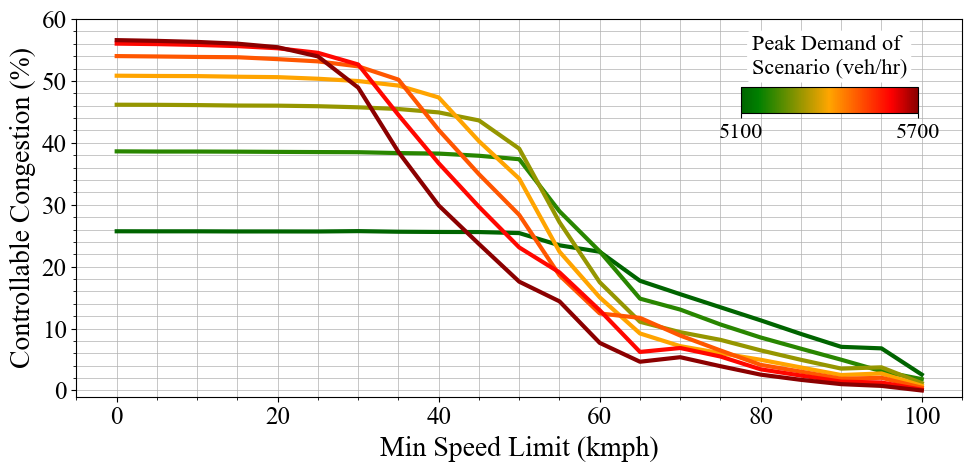

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import AutoMinorLocator

# -------------------------------------------------------------------
# Global style
# -------------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
text_fontsize = 20

fig, ax1 = plt.subplots(figsize=(10, 5))

# -------------------------------------------------------------------
# Custom colormap for demand (green → orange → red, then reversed)
# -------------------------------------------------------------------
colors = ["darkred", "red", "orange", "green", "darkgreen"]
vals   = [0, 0.15, 0.5, 0.9, 1.0]
cmap   = LinearSegmentedColormap.from_list("rg", list(zip(vals, colors)), N=256).reversed()

# If we need a demand-based color scale, define the normalization
demands = np.array(sorted(demand_dict.keys()))
dmin, dmax = demands.min(), demands.max()
norm = Normalize(vmin=dmin, vmax=dmax)

# -------------------------------------------------------------------
# Plot each scenario
# -------------------------------------------------------------------
for demand in demands:
    x = np.array(demand_dict[demand][1])
    y = np.array(demand_cc[demand])

    if identifier == "holdlen":
        ax1.plot(x * 10 / 60, y, marker="o", label=f"{demand} veh/hr")

    elif identifier == "speedlimit":
        # Color encodes demand
        color = cmap(norm(demand))
        ax1.plot(x, y, color=color, linewidth=3)

    elif additional_path == "spatial_safety":
        ax1.plot(x, y, marker="o", label=f"{demand} veh/hr")

    elif additional_path == "temporal_safety":
        ax1.plot(x[:13], y[:13], marker="o", label=f"{demand} veh/hr")

    elif identifier == "location":
        ax1.plot(x * L, y, marker="o", label=f"{demand} veh/hr")

# -------------------------------------------------------------------
# Axis labels depending on the case
# -------------------------------------------------------------------
if identifier == "holdlen":
    ax1.set_xlabel("Hold Length (min)", fontsize=text_fontsize)
elif identifier == "speedlimit":
    ax1.set_xlabel("Min Speed Limit (kmph)", fontsize=text_fontsize)
elif additional_path == "spatial_safety":
    ax1.set_xlabel("Max Change between Adjacent Segments (kmph)", fontsize=text_fontsize)
elif additional_path == "temporal_safety":
    ax1.set_xlabel("Max Change between Time Steps (kmph)", fontsize=text_fontsize)
elif identifier == "location":
    ax1.set_xlabel("Distance from entrance (km)", fontsize=text_fontsize)
    ax1.vlines(
        (num_segments - 5) * L,
        ymin=-1,
        ymax=55,
        colors="r",
        linestyles="dashed",
        label="Bottleneck",
    )

ax1.set_ylabel("Controllable Congestion (%)", fontsize=text_fontsize)
ax1.set_ylim(-1, 60)

# -------------------------------------------------------------------
# Legend (only if there are labeled artists)
# -------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()
if handles and identifier != "speedlimit":  # for speedlimit we use colorbar, not legend
    ax1.legend(loc="upper right")

# -------------------------------------------------------------------
# Colorbar for demand when using the colormap
# -------------------------------------------------------------------
if identifier == "speedlimit":

    # Create scalar mappable for the colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # --- Place a smaller colorbar inside the axes ---
    # [left, bottom, width, height] in axes fraction
    cax = ax1.inset_axes([0.75, 0.75, 0.20, 0.07]) 
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_ticks([dmin, dmax])

    cbar.set_label("Peak Demand of \nScenario (veh/hr)",
                   fontsize=text_fontsize-4, fontname="Times New Roman",
                   labelpad=10,
                       bbox=dict(facecolor="white", edgecolor="none", boxstyle="round, pad=0.2"),)
    cbar.ax.xaxis.set_label_position('top')

    # Tick label styling
    for tick in cbar.ax.get_yticklabels():
        tick.set_fontname("Times New Roman")
        tick.set_fontsize(text_fontsize - 2)


# -------------------------------------------------------------------
# Optional secondary y-axis for jam time
# -------------------------------------------------------------------
jam = False  # or True, depending on your run

if jam:
    ax2 = ax1.twinx()
    ax2.plot(
        np.array(constraint_range),
        jam_times,
        marker="x",
        color="r",
        label="Time until free flow (min)",
    )
    ax2.set_ylabel("Time until free flow (min)", color="r", fontsize=text_fontsize)
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    for label in ax2.get_yticklabels():
        label.set_fontname("Times New Roman")
        label.set_fontsize(text_fontsize - 2)

    # merge legends if needed
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    if h1 or h2:
        ax2.legend(h1 + h2, l1 + l2, loc="upper right")

# -------------------------------------------------------------------
# Ticks, grid, and layout
# -------------------------------------------------------------------
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontname("Times New Roman")
    label.set_fontsize(text_fontsize - 2)

ax1.grid(which="both", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig(f"min_speed_limit.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()


(719, 25)
(720, 25)


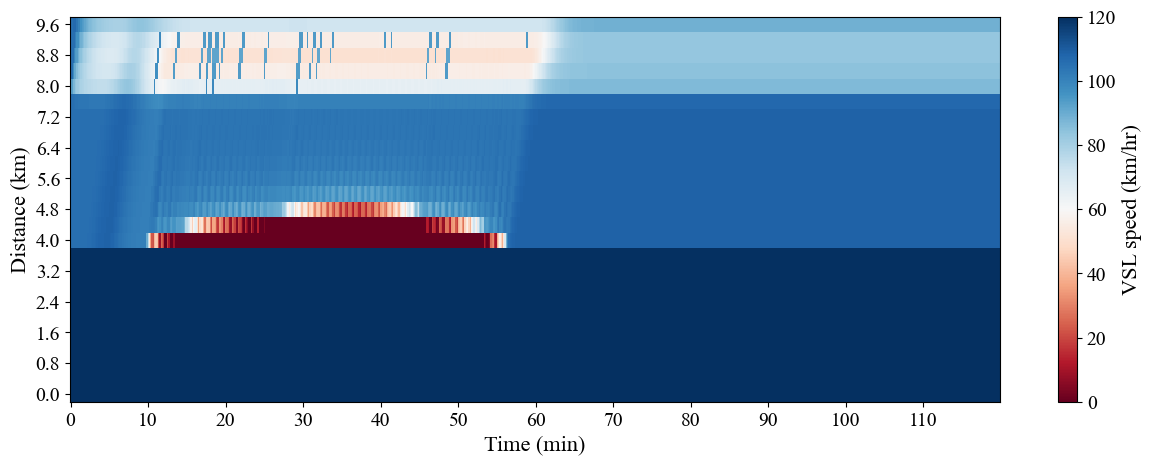

720 25


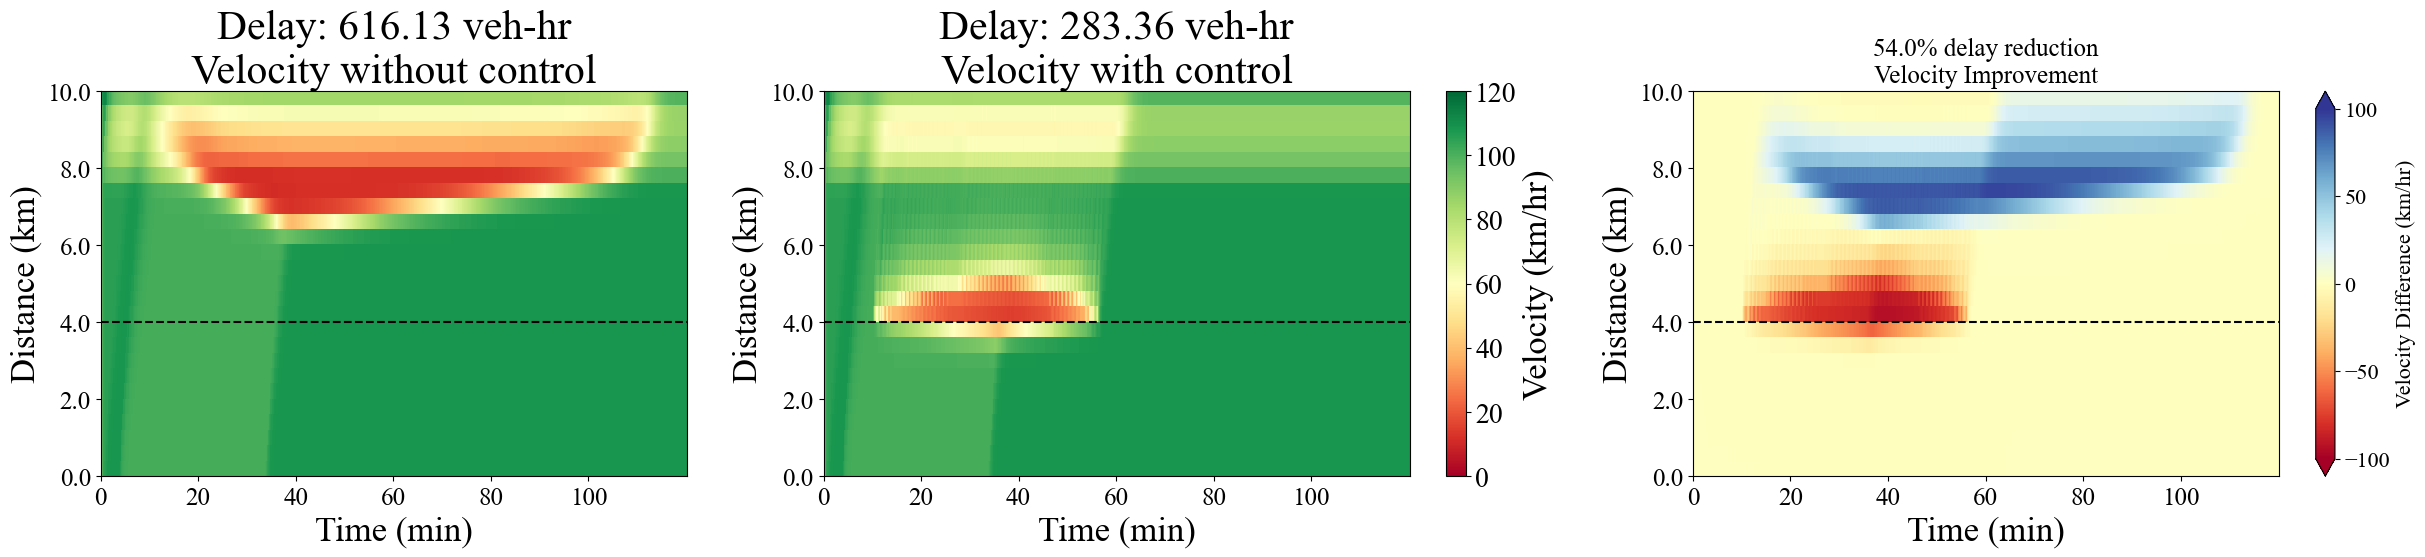

In [55]:
optimal_vsl = np.array(pd.read_csv('/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/demand/demand5500.0_duration0.5.csv'))
optimal_vsl2 = np.array(pd.read_csv('/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/min_speedlimit/demand5500/speedlimit0.csv'))

print(optimal_vsl.shape)
print(optimal_vsl2.shape)

plot_vsls(optimal_vsl2, sim_time, num_segments, i24params['v_free'][0], T=time_step, l=L)

plot_nocontrol_control(traffic_demand, downstream_density, optimal_vsl2, sim_lanes, i24params['v_free'][0], T=time_step, l=segment_len, plot_p=False, plot_q=False, params=i24params)

In [82]:
optimal_25 = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/holdlength/holdlen40.csv"))
velocities = metanet_sim_params(time_step, segment_len, start_traffic_state, optimal_25, traffic_demand, downstream_density, i24params,
                                            lanes=sim_lanes, real_data=False, plotting=True)[1]

velocities = np.flip(velocities.T, axis=0)



/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_next_space_bin = (space_current - ceil(space_current - 1)) / speed
/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_previous_space_bin = (floor(space_current + 1) - space_current) / speed


Mean vehicle travel time: 21.998784535302157 min
Standard deviation of vehicle travel time: 8.29076100123488 min


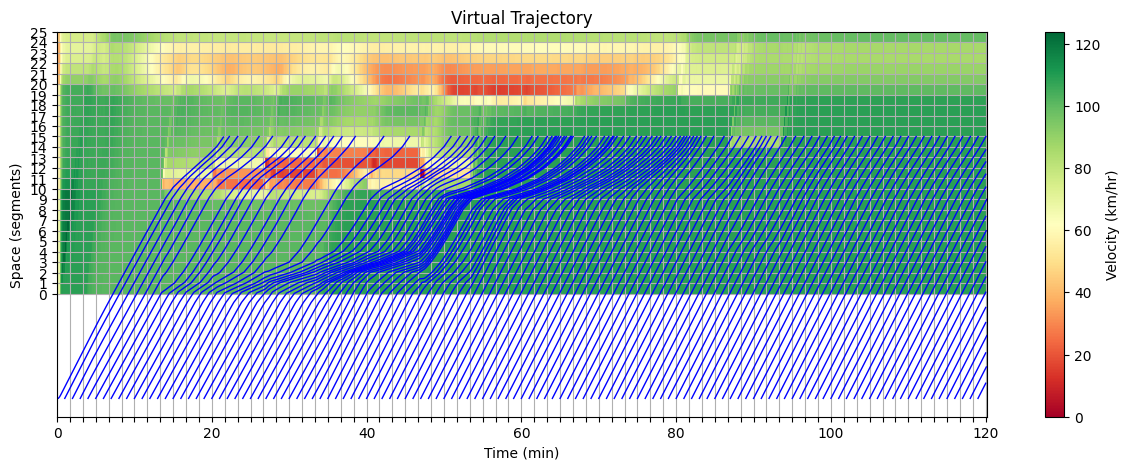

88.0


/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_next_space_bin = (space_current - ceil(space_current - 1)) / speed
/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_previous_space_bin = (floor(space_current + 1) - space_current) / speed


In [221]:
# print(velocities.shape)
no_control_times = vt_travel_time_stats(velocities, num_samples=121, plotting=True)
# print((no_control_times))

jam_time_25 = time_until_ff(velocities, time_step, sim_time, num_samples=121)
print(jam_time_25)
